https://huggingface.co/pyannote/embedding

In [6]:
from collections import namedtuple
AudioData = namedtuple('AudioData', ['file_name', 'mel', 'text', 'duration'])

In [7]:
from glob import glob

In [27]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib as mpl
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] =False
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [9]:
import torch
import torchaudio

In [10]:
import whisper
whisper_model = whisper.load_model("turbo")

In [11]:
from pyannote.audio import Model
from pyannote.audio import Inference
model = Model.from_pretrained("pyannote/embedding")

C:\Users\darke\.conda\envs\pyannote_env\lib\site-packages\pytorch_lightning\utilities\migration\migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\darke\.cache\torch\pyannote\models--pyannote--embedding\snapshots\4db4899737a38b2d618bbd74350915aa10293cb2\pytorch_model.bin`
C:\Users\darke\.conda\envs\pyannote_env\lib\site-packages\pyannote\audio\core\model.py:692: UserWarning: Model has been trained with a task-dependent loss function. Set 'strict' to False to load the model without its loss

Model was trained with pyannote.audio 0.0.1, yours is 3.3.2. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.8.1+cu102, yours is 2.6.0+cu126. Bad things might happen unless you revert torch to 1.x.
Model was trained with pyannote.audio 0.0.1, yours is 3.3.2. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.8.1+cu102, yours is 2.6.0+cu126. Bad things might happen unless you revert torch to 1.x.


In [12]:
import umap

In [13]:
audio_files = glob("./audio/*.mp3")
print(audio_files)

['./audio\\01.mp3', './audio\\02.mp3', './audio\\03.mp3', './audio\\04.mp3', './audio\\05.mp3', './audio\\06.mp3', './audio\\07.mp3', './audio\\08.mp3', './audio\\09.mp3']


In [14]:
audio_data_list = list() 

for audio_file in tqdm(audio_files):

    _, sample_rate = torchaudio.load(audio_file)
    audio = whisper.load_audio(audio_file)
    duration = audio / sample_rate
    audio = whisper.pad_or_trim(audio)
    
    mel = whisper.log_mel_spectrogram(audio, n_mels=whisper_model.dims.n_mels).to(whisper_model.device)
    options = whisper.DecodingOptions(language="ko")
    
    result = whisper.decode(whisper_model, mel, options)
    
    print(result.text)

    audio_data = AudioData(audio_file, mel, result.text, duration)
    audio_data_list.append(audio_data)

  0%|          | 0/9 [00:00<?, ?it/s]

왜 나이를 먹어가면서 점점 이해가 안 되는 게 많지? 아재들이 자꾸 이해하려고 하듯이 되네?
사람들이 왜 7개월 동안 남아있을 때 너는 롱키면서 칠가이
근데 이거 원작자랑 상관없이 그냥 만들어도 돼? 하긴 이것도 이 칠가의 작가님한테 안 물어보고 그냥 했네? 호의는 이 저작권 이게 없나 봐
이 후드티처럼 청천히 앞서갔어요.
이렇게 될 줄 어떻게 아냐고 이걸 어떻게 알아? 이거 돌이켜봤을 때 여기가 사그리다 파밀리아 천장일 거 같아 딱 이렇게 사그리다 파밀리아가 만들어질 거 같지 않아? 여기서 어떻게 들어가? 나 이거 너무 무서운데 나 이거 지금? 라고 할 때?
아 씨! ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ

In [35]:
inference = Inference(model, window="sliding", duration=1.0, step=0.5)

embeddings = list()

for audio_file in tqdm(audio_files):
    embedding = inference(audio_file).data
    embeddings.append(embedding)

C:\Users\darke\.conda\envs\pyannote_env\lib\site-packages\pyannote\audio\core\inference.py:135: UserWarning: Model was trained with 5s chunks, and you requested 1s chunks for inference: this might lead to suboptimal results.
  warnings.warn(


  0%|          | 0/9 [00:00<?, ?it/s]

In [36]:
concat = np.concatenate(embeddings, axis=0)

In [37]:
umap_model = umap.UMAP(n_components=2, metric='cosine')
X_umap = umap_model.fit_transform(concat)

C:\Users\darke\.conda\envs\pyannote_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


C:\Users\darke\AppData\Local\Temp\ipykernel_3868\3090867926.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(X_umap[:, 0], X_umap[:, 1], cmap='viridis', s=25, alpha=0.6)


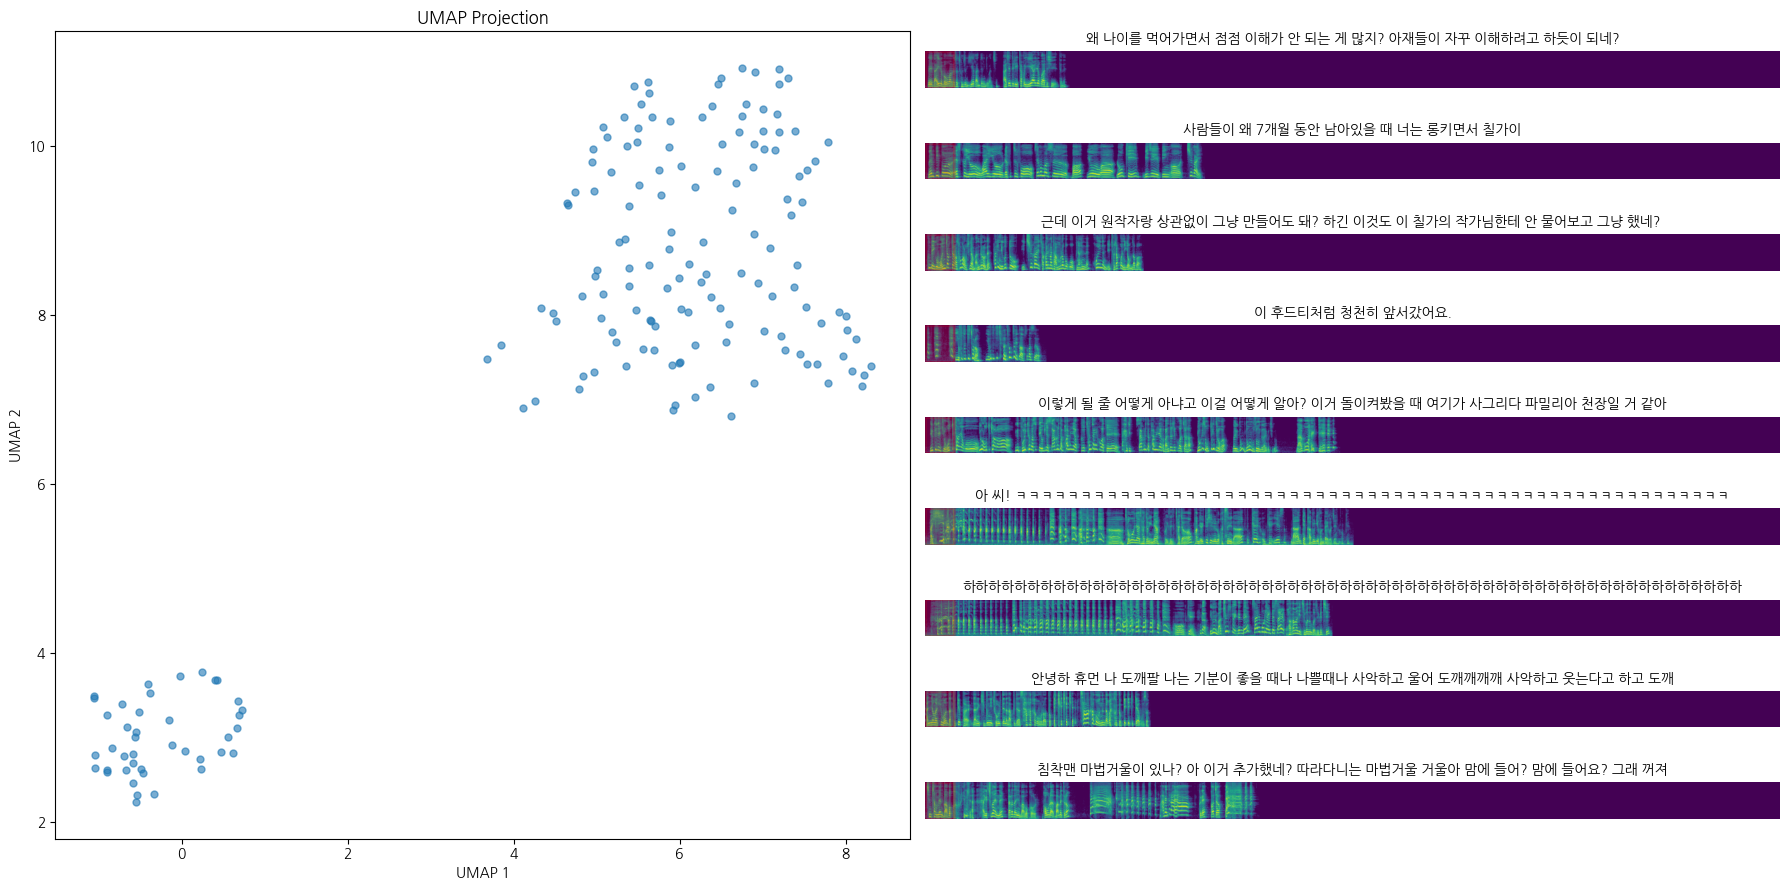

In [39]:
fig = plt.figure(figsize=(18, 9))

gs = fig.add_gridspec(9, 2, width_ratios=[9, 9]) 

ax1 = fig.add_subplot(gs[:, 0])
ax1.scatter(X_umap[:, 0], X_umap[:, 1], cmap='viridis', s=25, alpha=0.6)
ax1.set_title("UMAP Projection")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")

for i, audio_data in enumerate(audio_data_list):
    ax = fig.add_subplot(gs[i, 1])  
    ax.axis('off')  
    ax.set_title(f"{audio_data.text[:60]}", fontsize=10)
    ax.imshow(audio_data.mel.cpu(), origin='lower')

    x, y, width, height = 0, 0, 100, 128
    rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='red', alpha=0.2)
    ax.add_patch(rect)

plt.tight_layout()
plt.show()